# Hirano MSC-LS circuit atlas and two-fault diagnosis

This notebook maps the released `experiment-2025-sep` Figure-9 circuit and its
exact two-fault witnesses to physical operations and detector records.

**Result.** The distance-5 surface patch passes through a three-round
spacetime neck. Its minimum undetected logical needs three faults, but decoded
surface syndromes admit ambiguous two-fault histories. Consequently the
finite-window slope near 2.7 is a mixture of $p^2$ and $p^3$, not a fractional
distance. The notebook uses exact enumeration and deterministic injections—no
large Monte Carlo run. Figure 9 is a Clifford diagnostic with an ideally
prepared Steane state, not the non-Clifford cultivation circuit.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymatching
from scipy.optimize import nnls
import stim
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
assert (ROOT / "src" / "lattice_surgery_error_detection.py").exists()
sys.path.insert(0, str(ROOT / "audit"))

from fig9_postselection_audit import KNOWN_AMBIGUITIES
from hirano_protocol_notebook_helpers import (
    build_protocol,
    detector_registry,
    deterministic_fault_circuit,
    fault_table,
    plot_grouped_hirano_interface_round,
    plot_grouped_post_interface,
    plot_grouped_pre_interface,
    plot_d16_d46_d77_spacetime,
    plot_protocol_layout,
    semantic_labels,
    show_timeline,
    show_timeslices,
    single_fault_decoder_failures,
    witness_summary,
)

print(f"Stim {stim.__version__}; PyMatching {pymatching.__version__}")
print("Released source under audit: src/lattice_surgery_error_detection.py")
print("No Monte Carlo shots are used in this notebook.")

Stim 1.15.0; PyMatching 2.3.1
Released source under audit: src/lattice_surgery_error_detection.py
No Monte Carlo shots are used in this notebook.


## 1. Paper claim versus the two code branches

The paper postselects color/interface syndromes but decodes surface syndromes.
The released code instead exposes `full_post_selection`:

- `False`: 40 selected color/interface/heuristic surface detectors are
  postselected; the remaining surface history is decoded. Four extra noisy
  surface rounds are appended after the first recovery round.
- `True`: omit those four rounds and postselect all 135 detectors.

The released Figure-9 counts match `True`, which is stronger than the paper's
general decoded-surface description. See the paper's Section III A and Figures
5, 6, and 9.

In [2]:
branch_rows = []
for full in (False, True):
    wrapper = build_protocol("+", error_probability=0.001, full_post_selection=full)
    circuit = wrapper.circuit.circuit
    postselected = {item.id for item in wrapper.circuit.detectors_for_post_selection}
    tags = []
    for instruction in circuit.flattened():
        if instruction.name == "DETECTOR":
            tags.append(instruction.tag or "untagged")
    branch_rows.append(
        {
            "full_post_selection": full,
            "TICKs": circuit.num_ticks,
            "measurements": circuit.num_measurements,
            "detectors": circuit.num_detectors,
            "postselected_detectors": len(postselected),
            "decoded_detector_columns": circuit.num_detectors - len(postselected),
            "postselected tags": dict(pd.Series([tags[i] for i in postselected]).value_counts()),
        }
    )
branch_table = pd.DataFrame(branch_rows)
display(branch_table)

,full_post_selection,TICKs,measurements,detectors,postselected_detectors,decoded_detector_columns,postselected tags
0,False,56,266,231,40,191,"{'POST-SELECTION': 22, 'SURFACE-X': 18}"
1,True,32,170,135,135,0,"{'SURFACE-X': 53, 'SURFACE-Z': 48, 'POST-SELEC..."


## 2. Protocol schedule in the released circuit

Stim ticks are circuit layers, not syndrome rounds. `Stabilize_*` marks
zero-duration separators inside the pipelined color schedule:

| Stim interval | Released-code action |
|---|---|
| before / ticks 0–5 | initialize the distance-5 surface data in $|+\rangle$ and complete one ordinary surface-check round |
| ticks 6–11 | Hirano lattice-surgery Z-syndrome round 1; remove the conflicting top surface-X checks; begin the pipelined direct color checks |
| tick 12 | tagged `Stabilize_0` separator |
| ticks 13–18 | Hirano lattice-surgery Z-syndrome round 2; continue/finish the pipelined color checks |
| tick 19 | tagged `Stabilize_1` separator |
| ticks 20–25 | Hirano lattice-surgery Z-syndrome round 3; finish direct checks; destructively X-measure Steane data and obtain $X_{ab}$ |
| ticks 26–31 | recover $X_{ab}$ and $X_{cd}$ and perform one ordinary surface round |
| ticks 32–55 | only when `full_post_selection=False`: four further ordinary surface rounds for decoding |
| after the last tick | noiseless destructive X (`+` probe) or Z (`0` probe) surface readout and `L0` parity |

The interface checks are $Z_{1a}$, $Z_{35bc}$, and $Z_{de}$. Compatible surface
checks continue; color extraction is pipelined across round boundaries; and
demolition supplies the missing X checks.

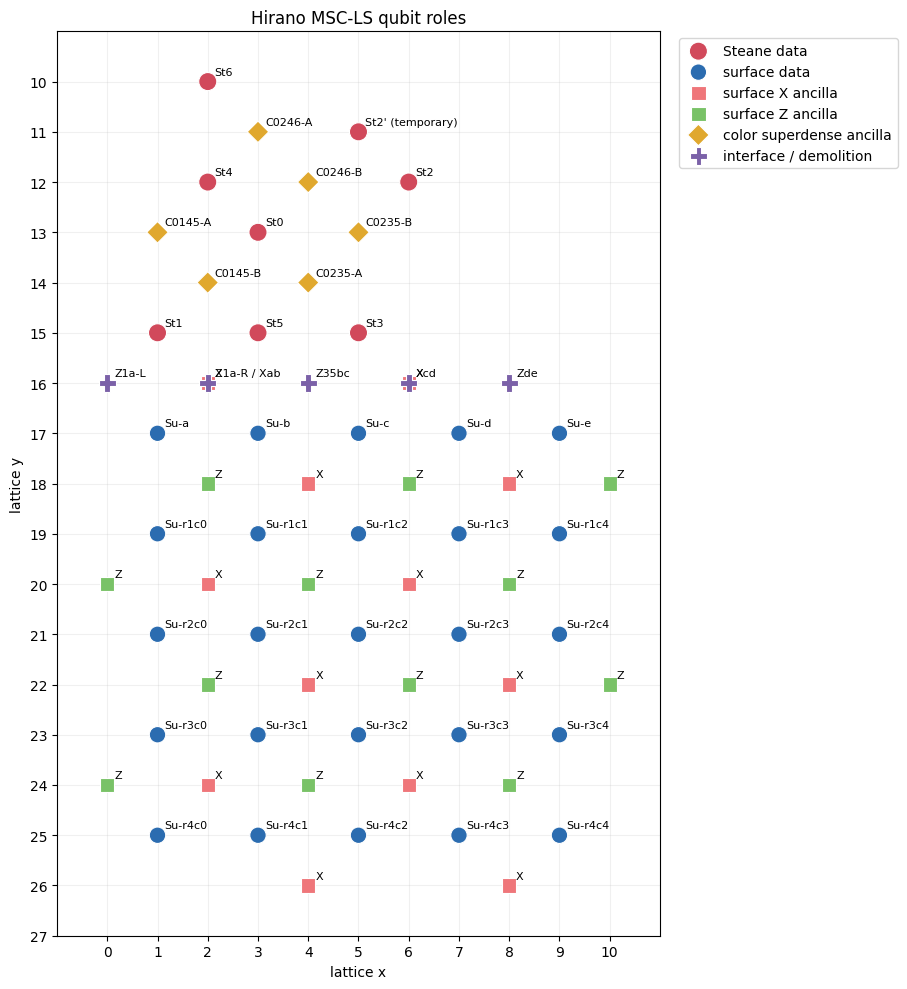

In [3]:
noiseless = build_protocol("+", error_probability=0.0, full_post_selection=False)
labels = semantic_labels(noiseless)
plot_protocol_layout(noiseless);

### Before the interface rounds: complete macro-operation atlas

Beginning-to-end atlas for the decoded `+`, ZXZ branch. Each operation has one
owner panel. Steane code expansion is collapsed, as are the hardware sublayers
of complete surface checks. `D0`, `D1`, `F`, and `L0` are classical records,
not repeated measurements. Black/red annotations anticipate the detector
witness explained in Section 3.

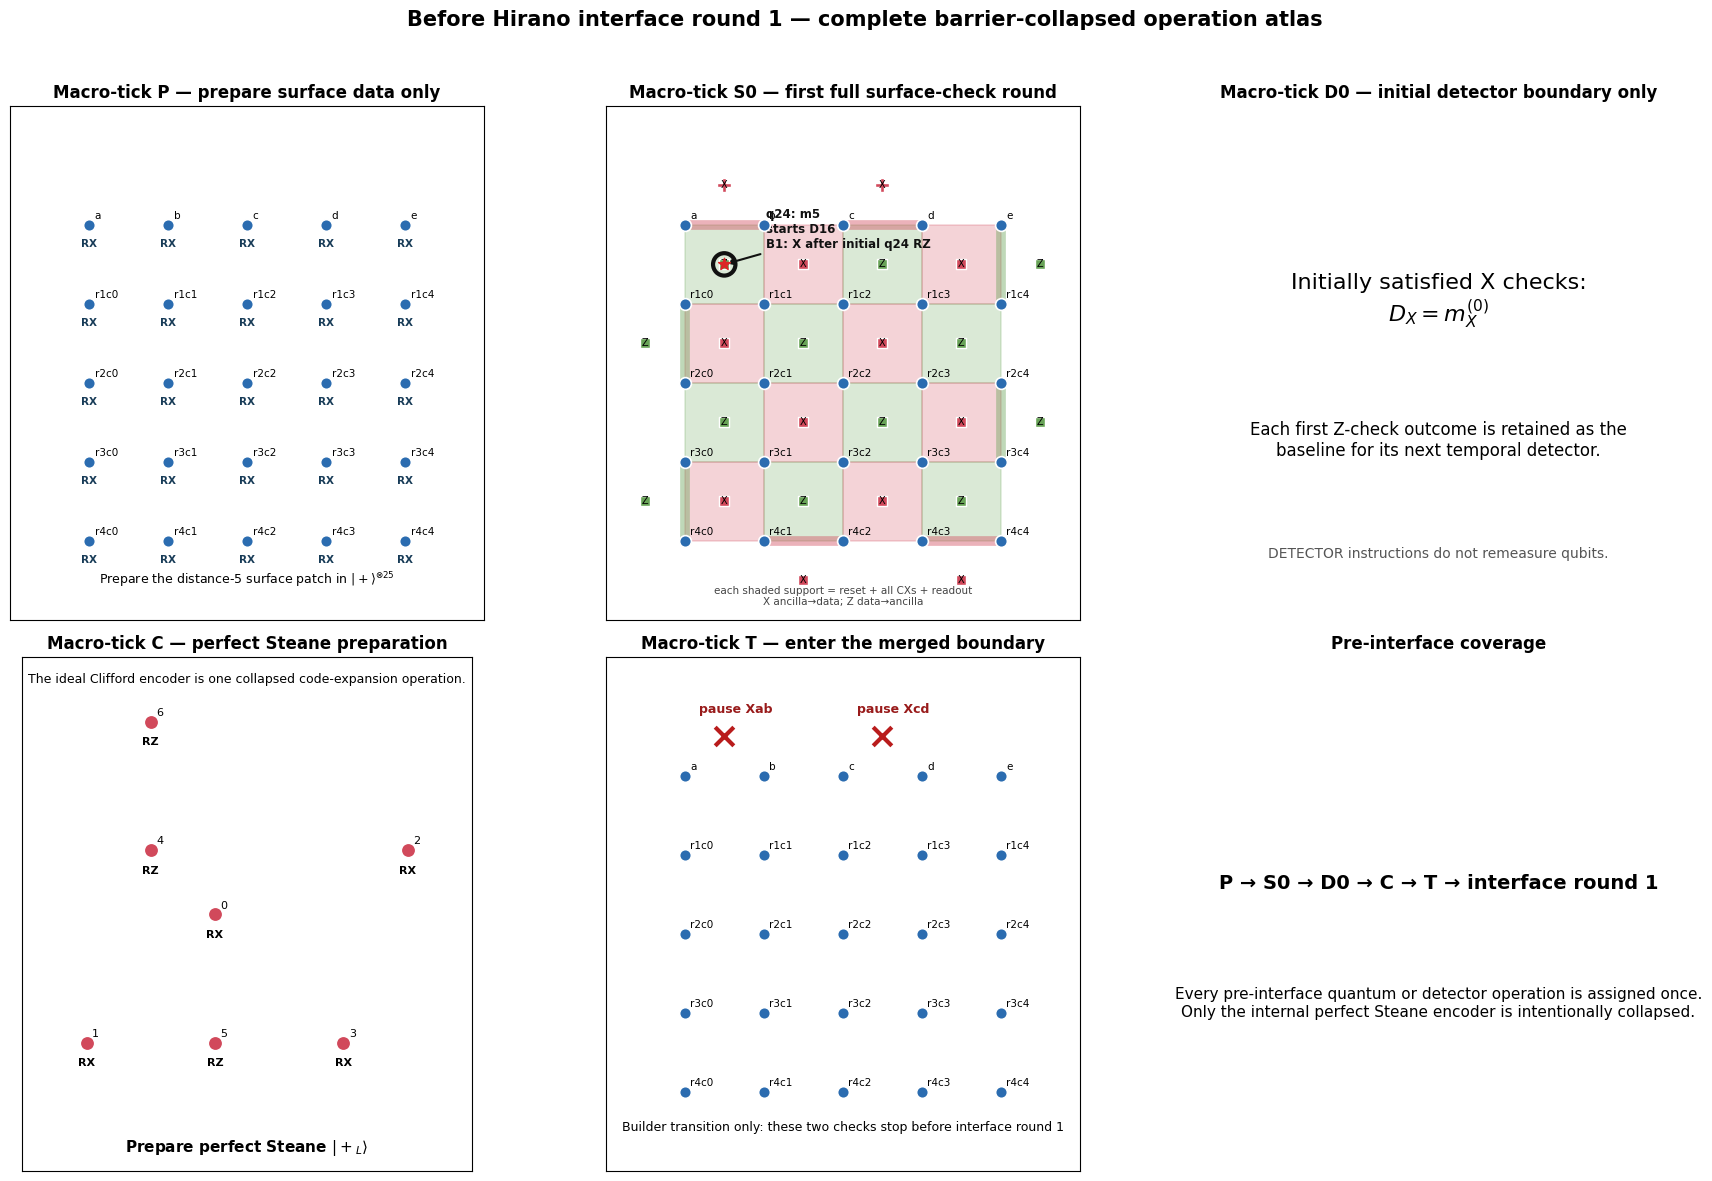

In [4]:
pre_figure = plot_grouped_pre_interface(noiseless, probe="+", detector_overlay=True)
display(pre_figure)
plt.close(pre_figure)

### Literal Stim geometry during Hirano interface round 1

This is Stim's timeslice view. Use it together with the semantic layout above:
the timeslice answers *where* simultaneous operations happen, while the
timeline answers *in what order* records and detectors are produced.

In [5]:
show_timeslices(
    noiseless.circuit.circuit,
    labels,
    ticks=range(6, 12),
    zoom=0.9,
)

### Interface rounds 1–3: operation-family macro-ticks

Hirano calls these the three *lattice-surgery Z-syndrome rounds*. Each spans
six executable layers. The macro panels collapse barriers into logical owners:

| panel | content |
|---|---|
| I / S | three interface-Z checks / all compatible surface checks |
| B | genuine color-ancilla Bell-pair preparation; round 2 also owns the fresh $q_2/q_{2'}$ Z-copy |
| Z / X | Steane Z/X couplings; the second direct extraction has no X coupling |
| M | color-ancilla disentangling, readout, and postselected color records |
| C | round-1 source-order $q_2/q_{2'}$ route: $ZZ=+1$ repetition, data move, then $XX=+1$ repetition and return |
| D / A / P | round-3 Steane demolition, q23 $X_{ab}$, and derived parities |

Round 1 uses `Z1a-R`, round 2 uses `Z1a-L`, and round 3 returns to
`Z1a-R`. The ordinary $X_{ab},X_{cd}$ recovery begins only afterward.

The tall round-1 C panel is chronological. Solid boxes own the direct
$q_2/q_{2'}$ gates; dashed boxes merely point to the one matching CNOT arrow in
Z or X. In the released source the split is $q_2\to0235$-B and
$q_{2'}\to0246$-B for Z, then $0246$-B$\to q_{2'}$ and
$0235$-B$\to q_2$ for X.

Every source operation is assigned once. Complete checks and pipelined logical
extractions are collapsed; the panels preserve gate ownership and CNOT
direction, not hardware barriers. Black rings and red stars mark the Section-3
detector witness.

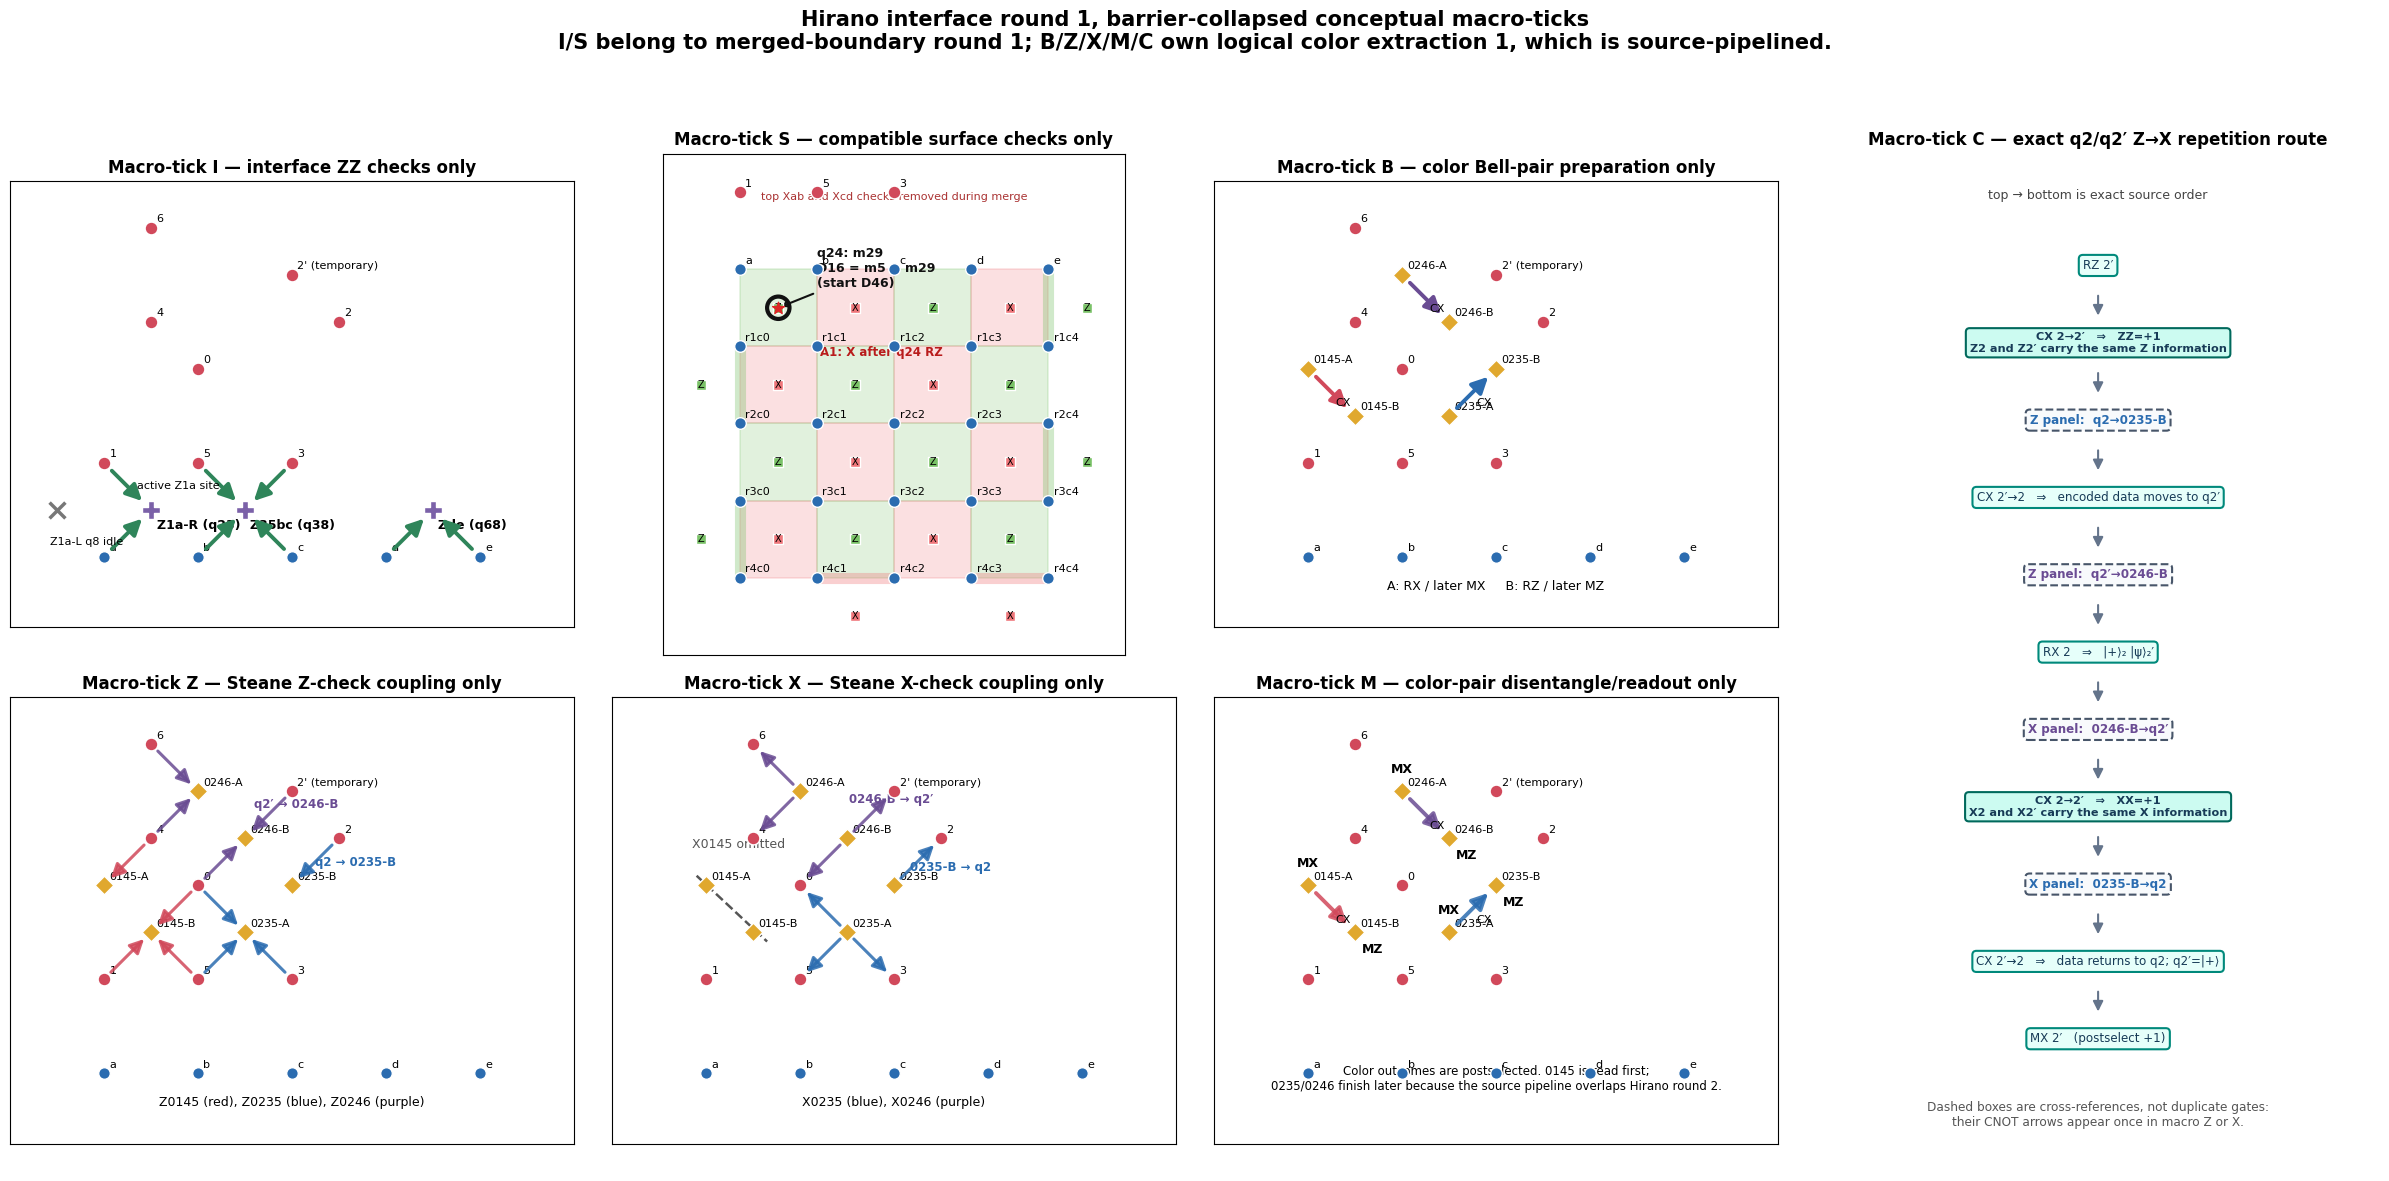

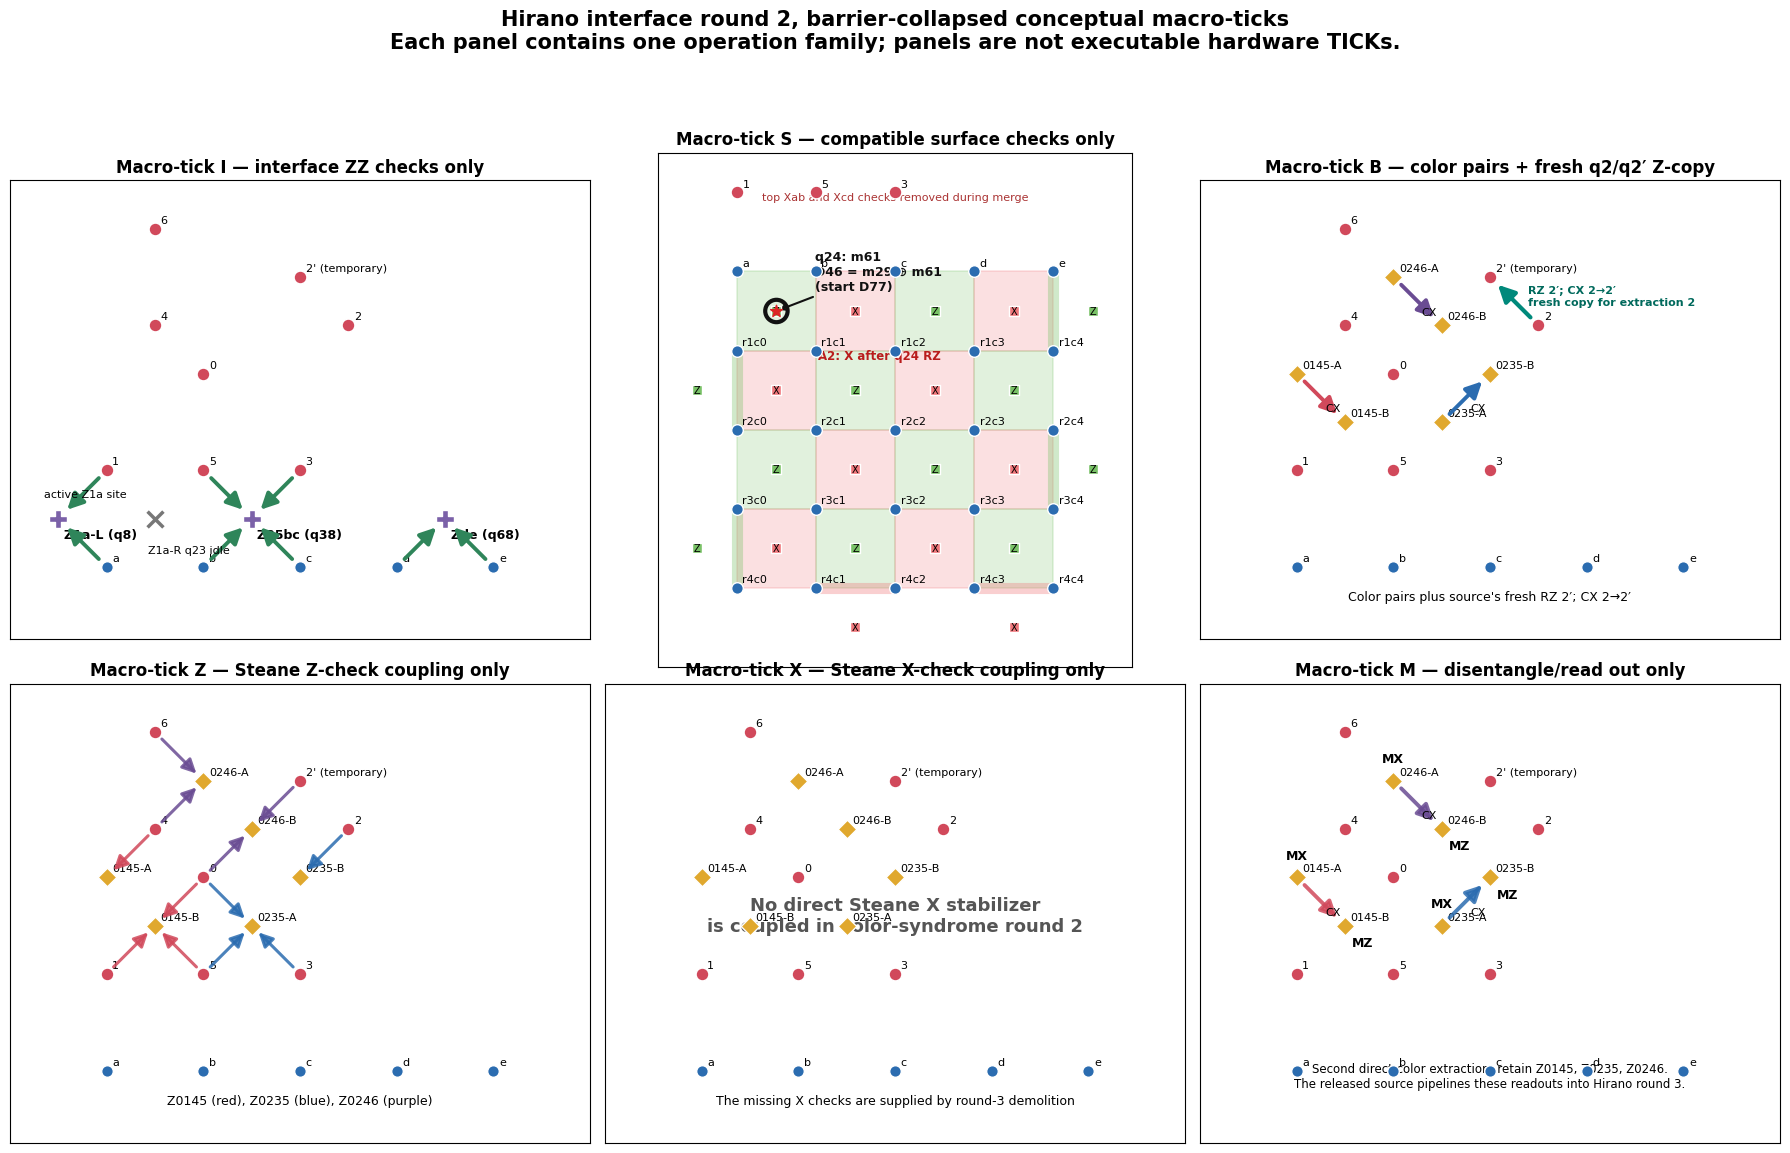

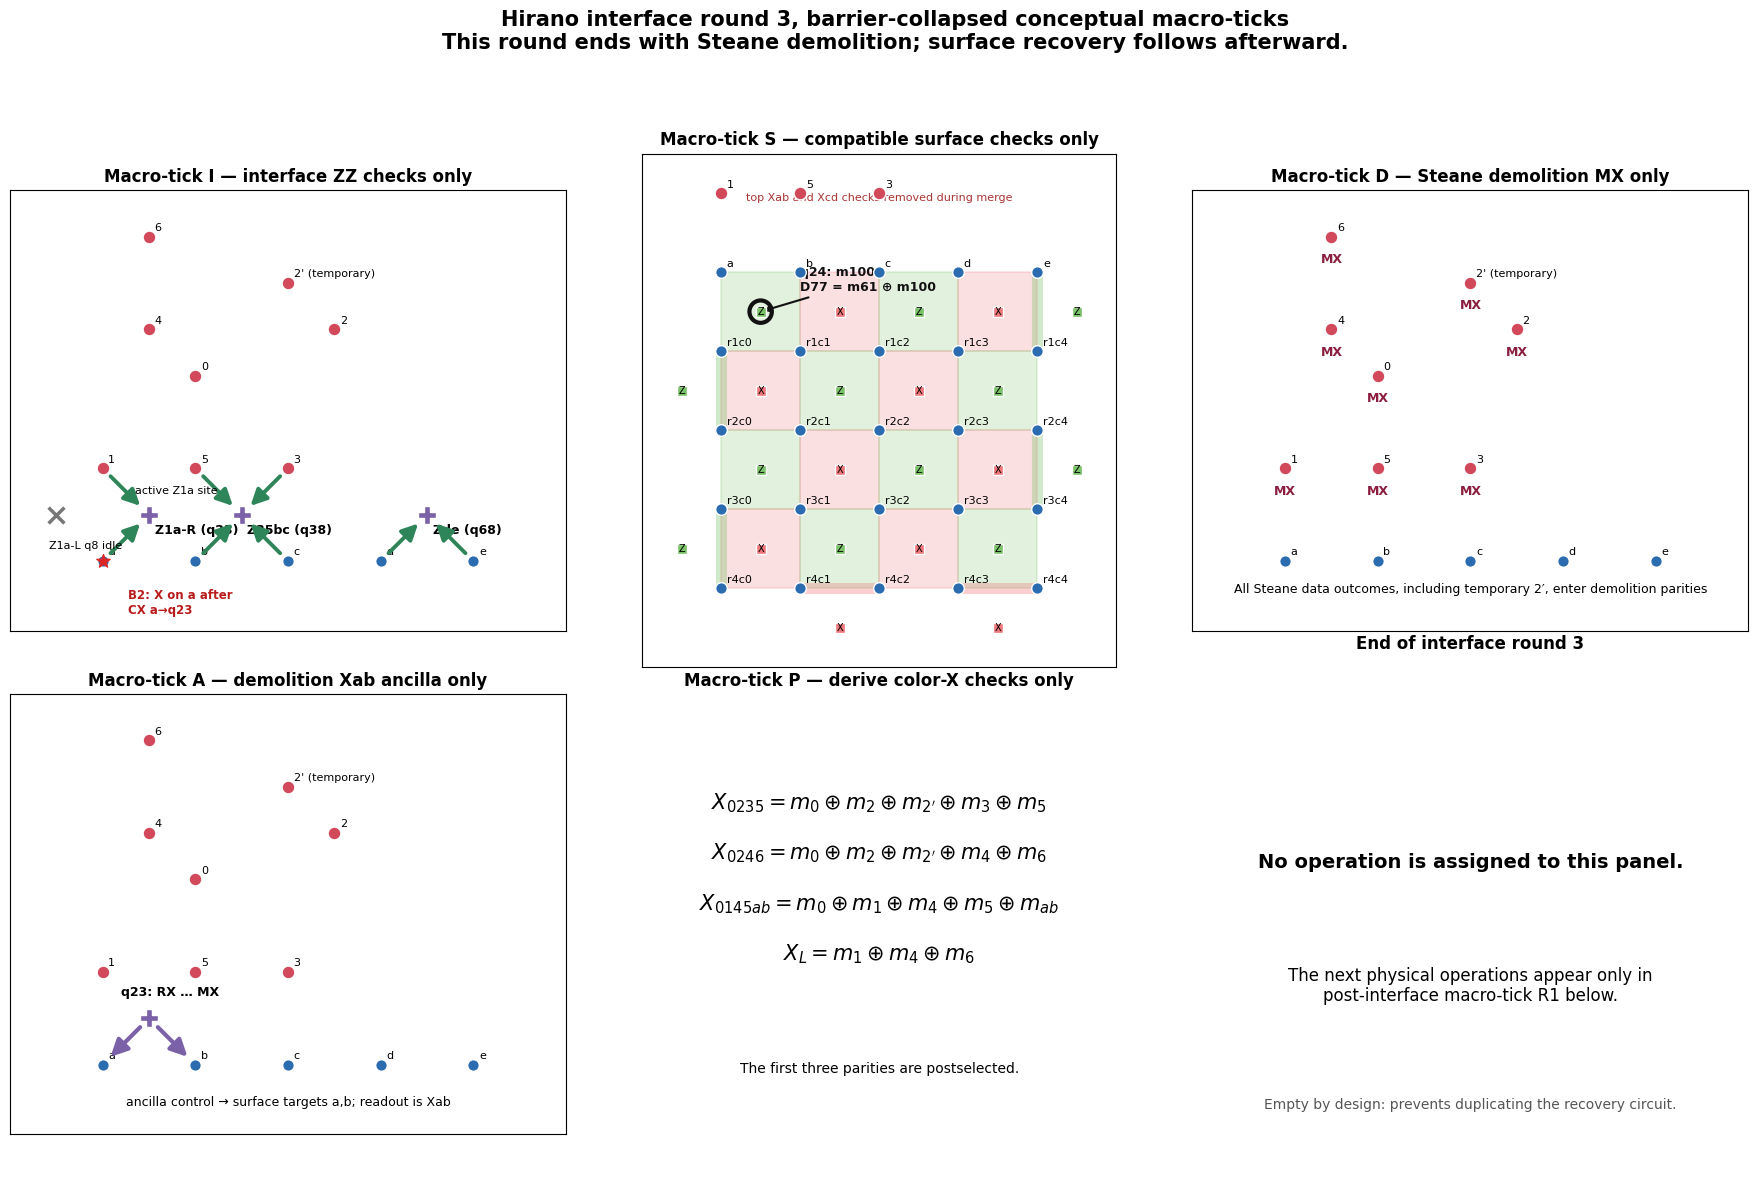

In [6]:
for round_number in (1, 2, 3):
    figure = plot_grouped_hirano_interface_round(
        noiseless,
        round_number,
        detector_overlay=True,
    )
    display(figure)
    plt.close(figure)

### After the interface rounds: recovery, decoded rounds, and final readout

Macro A's demolition $X_{ab}$ and R1's recovered $X_{ab}$ are consecutive
physical measurements, not a duplicated drawing. The first enters
$X_{0145ab}$; the second restarts the surface history:

$$D_{X_{ab}}=m_{ab}^{\rm demolition}\oplus m_{ab}^{\rm recovery}.$$

`D1` is this classical comparison, not a third measurement. The decoded branch
then runs four more surface rounds. For the `+` probe, the end is destructive
`MX`, classical X-detector closure, and `L0`; the `0` probe uses the analogous
Z quantities.

Macro M creates the final 25 data-measurement bits. Macro F then XORs those
already stored bits with each check ancilla's last stored result. That is why F
is drawn after demolition: it consumes demolition records; it does not apply a
gate or try to remeasure a destroyed qubit.

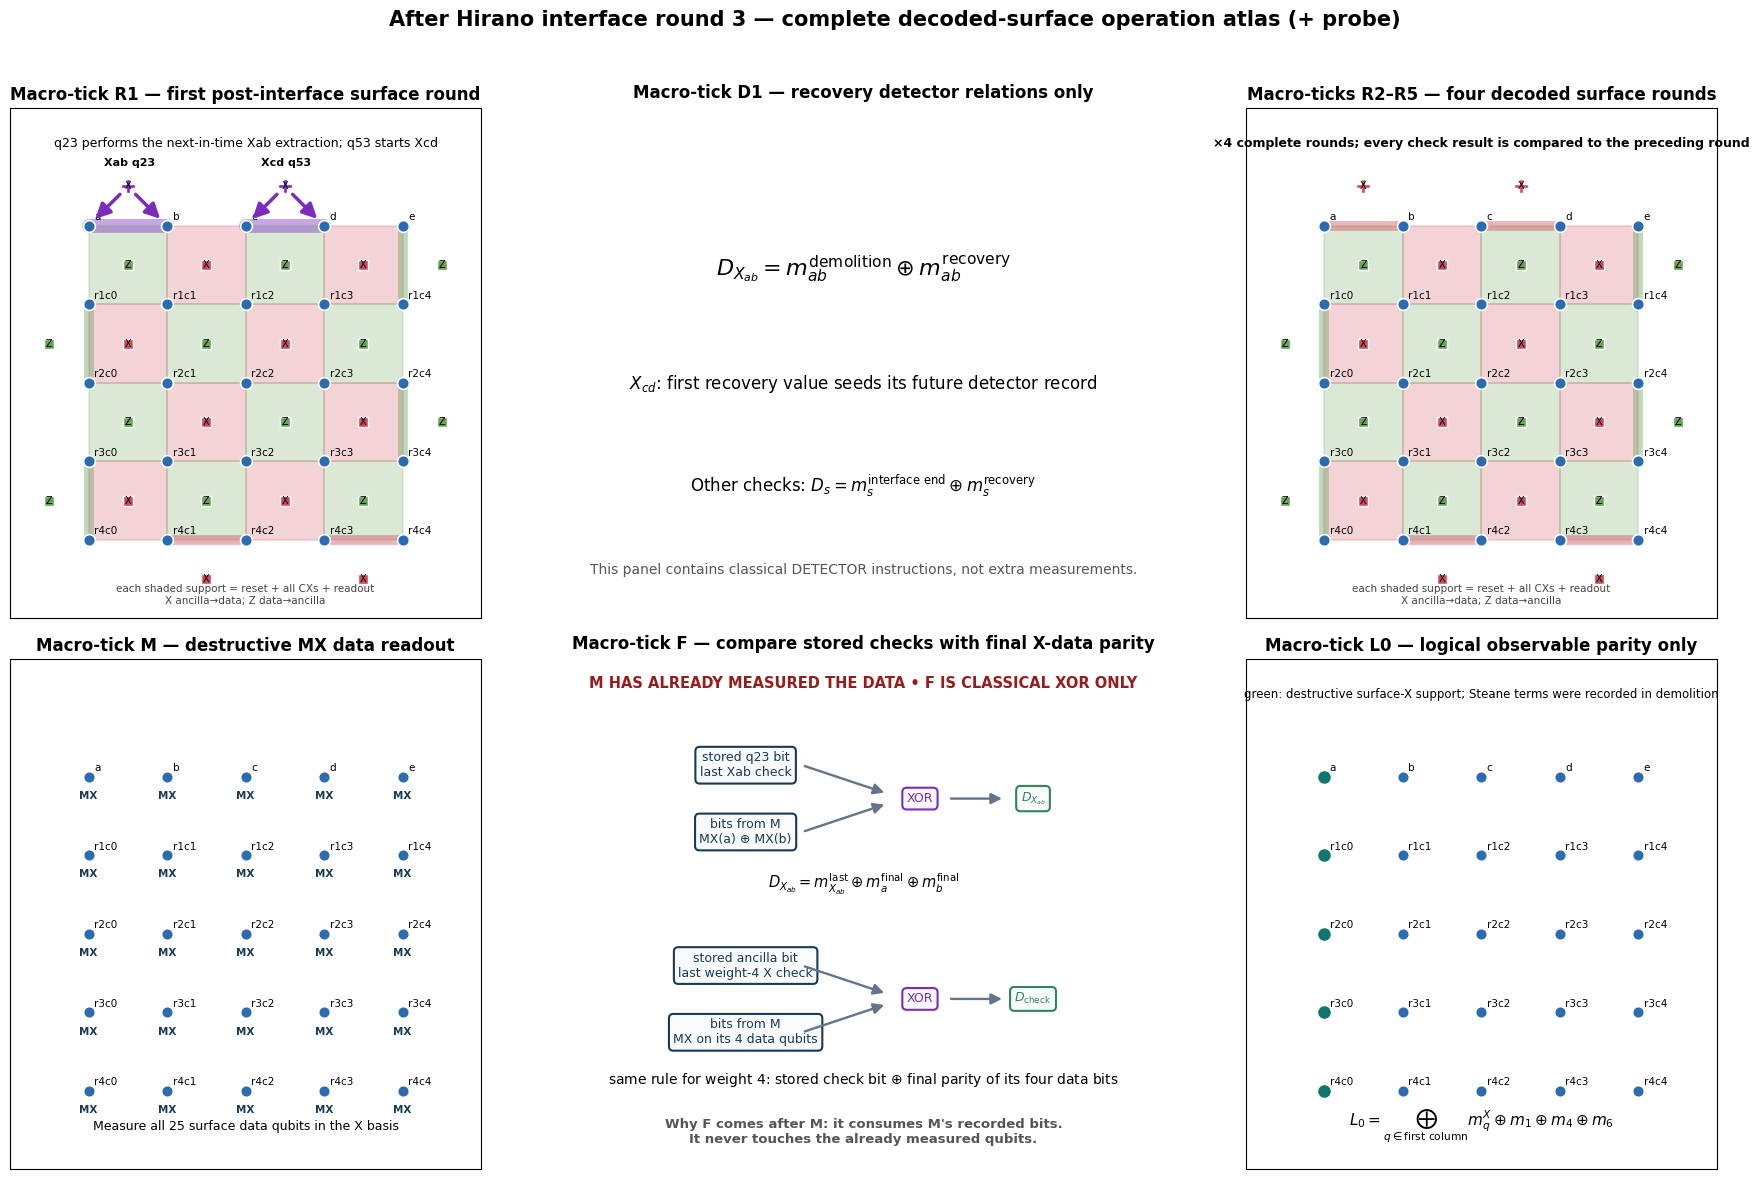

In [7]:
post_figure = plot_grouped_post_interface(
    noiseless,
    probe="+",
    full_post_selection=False,
)
display(post_figure)
plt.close(post_figure)

## 3. Where `D16`, `D46`, and `D77` are—and why they matter

They are three **time edges of one surface-Z check**, not qubits or gates. Its
ancilla is q24 at $(2,18)$ and its support is $\{a,b,r1c0,r1c1\}$:

$$D_{16}=m_5\oplus m_{29},\qquad
D_{46}=m_{29}\oplus m_{61},\qquad
D_{77}=m_{61}\oplus m_{100}.$$

The four q24 records occur in the initial surface round and interface rounds
1–3. In the macro atlas q24 is black-ringed; red stars mark the exact
`0`-probe ambiguity:

- history A: q24 reset faults in rounds 1 and 2 give
  $(D16\oplus D46)\oplus(D46\oplus D77)=D16\oplus D77$;
- history B: an initial q24 reset fault gives D16; an X component on data $a$
  after the round-3 `CX a→q23` gives D77 and flips `L0`.

Thus both accepted histories show the decoder $\{D16,D77\}$ but have opposite
logical values. This is one temporal chain at the **top-left
surface/interface corner**. It is decoded when `full_post_selection=False` and
rejected when every detector is postselected.

,detector,q24 parity,connects
0,D16,m5 ⊕ m29,initial → interface 1
1,D46,m29 ⊕ m61,interface 1 → 2
2,D77,m61 ⊕ m100,interface 2 → 3


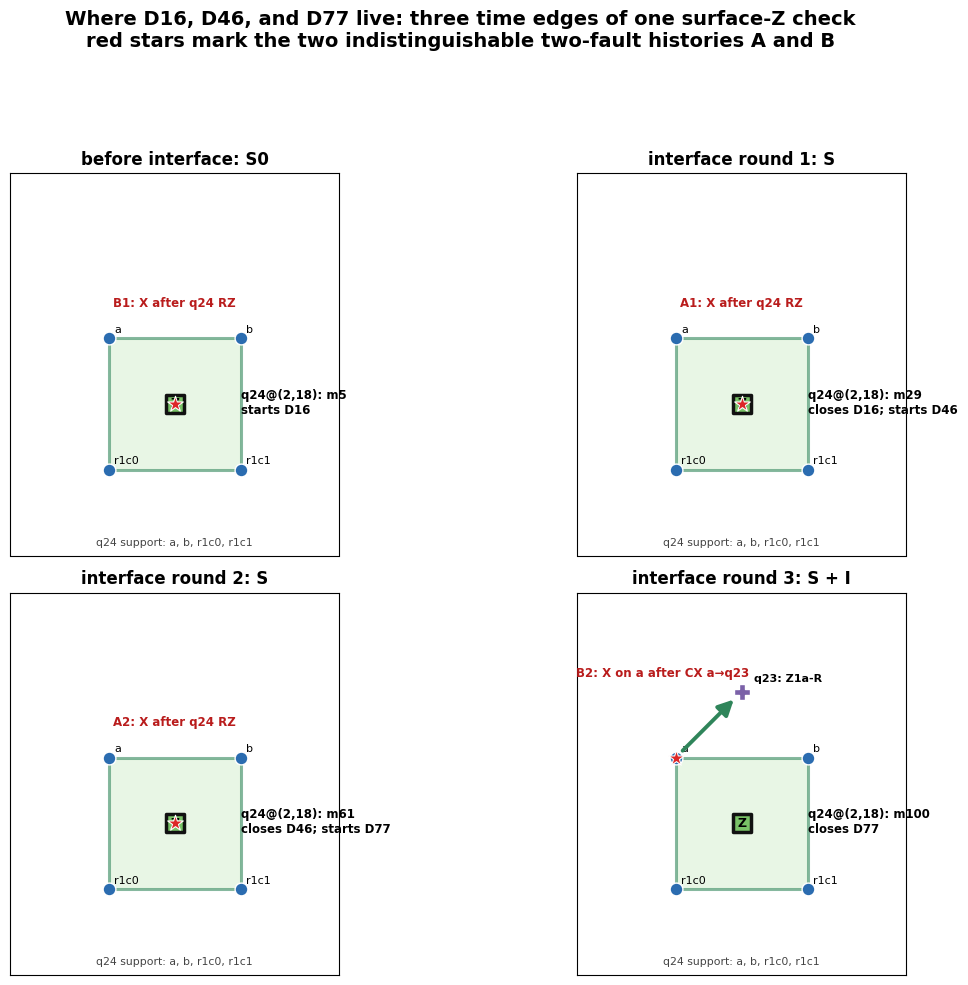

In [8]:
zero_for_detectors = build_protocol("0", error_probability=0.001, full_post_selection=False)
registry = detector_registry(zero_for_detectors, [16, 46, 77])
assert registry["coordinates"].map(lambda xs: xs == [(2, 18), (2, 18)]).all()
assert registry["measurement_ids"].tolist() == [[5, 29], [29, 61], [61, 100]]
assert "I: Z1a right / demolition Xab" in semantic_labels(zero_for_detectors).values()

display(pd.DataFrame({
    "detector": ["D16", "D46", "D77"],
    "q24 parity": ["m5 ⊕ m29", "m29 ⊕ m61", "m61 ⊕ m100"],
    "connects": ["initial → interface 1", "interface 1 → 2", "interface 2 → 3"],
}))

detector_figure = plot_d16_d46_d77_spacetime(zero_for_detectors)
display(detector_figure)
plt.close(detector_figure)

## 4. “Two-fault witness” in plain language

Fault effects combine by XOR:

$$d_{ij}=d_i\oplus d_j,\qquad \ell_{ij}=\ell_i\oplus\ell_j.$$

A witness is two accepted two-fault histories with identical decoded detector
bits but opposite `L0`. No decoder using only those bits can classify both, so
the accepted rate has a nonzero $O(p^2)$ term. `L0` is Stim observable 0; `+`
probes logical-Z errors and `0` probes logical-X errors.

In [29]:
plus_wrapper, plus_effects, plus_pairs = witness_summary("+")
zero_wrapper, zero_effects, zero_pairs = witness_summary("0")

assert single_fault_decoder_failures(plus_wrapper, plus_effects) == []
assert single_fault_decoder_failures(zero_wrapper, zero_effects) == []

print("+ probe (logical-Z-error diagnostic)")
display(plus_pairs)
print("0 probe (logical-X-error diagnostic)")
display(zero_pairs)
print("No accepted elementary one-fault effect is misdecoded in either probe.")

+ probe (logical-Z-error diagnostic)


,pair,effect_indices,common_accepted_syndrome,actual_L0,PyMatching_prediction,decoder_result
0,A,"(186, 246)","[D16, D22, D25, D56]",0,1,logical failure
1,B,"(206, 341)","[D16, D22, D25, D56]",1,1,correct


0 probe (logical-X-error diagnostic)


,pair,effect_indices,common_accepted_syndrome,actual_L0,PyMatching_prediction,decoder_result
0,A,"(212, 818)","[D16, D77]",0,1,logical failure
1,B,"(185, 1350)","[D16, D77]",1,1,correct


No accepted elementary one-fault effect is misdecoded in either probe.
+ probe (logical-Z-error diagnostic)


,pair,effect_indices,common_accepted_syndrome,actual_L0,PyMatching_prediction,decoder_result
0,A,"(186, 246)","[D16, D22, D25, D56]",0,1,logical failure
1,B,"(206, 341)","[D16, D22, D25, D56]",1,1,correct


0 probe (logical-X-error diagnostic)


,pair,effect_indices,common_accepted_syndrome,actual_L0,PyMatching_prediction,decoder_result
0,A,"(212, 818)","[D16, D77]",0,1,logical failure
1,B,"(185, 1350)","[D16, D77]",1,1,correct


No accepted elementary one-fault effect is misdecoded in either probe.


### `+` probe: hook-like witness

History A has two correlated faults after surface-syndrome CNOTs. History B has
the same accepted syndrome and opposite logical class. `D17` cancels in A and
`D21` in B; both are postselected surface-X detectors.

In [30]:
plus_indices = sorted({i for pair in KNOWN_AMBIGUITIES["+"] for i in pair})
display(fault_table(plus_wrapper, plus_effects, plus_indices))

,effect,detectors,L0,after_TICKs,noise_instruction,representative_Pauli,instruction_offset
0,186,"[D16, D17]",0,8,"DEPOLARIZE2(0.001) 39[coords 4,18] 263[coords ...","YSu-X[b,r1c1,c,r1c2]@(4, 18) * YSu-c@(5, 17)",900
1,206,"[D16, D21]",1,2,"DEPOLARIZE2(0.001) 234[coords 1,19] 24[coords ...","YSu-r1c0@(1, 19)",587
2,246,"[D17, D22, D25, D56]",0,8,"DEPOLARIZE2(0.001) 250[coords 3,21] 40[coords ...","XSu-r2c1@(3, 21) * YSu-Z[r1c1,r2c1,r1c2,r2c2]@...",912
3,341,"[D21, D22, D25, D56]",0,7,"DEPOLARIZE2(0.001) 41[coords 4,22] 250[coords ...","YSu-r2c1@(3, 21)",862


,effect,detectors,L0,after_TICKs,noise_instruction,representative_Pauli,instruction_offset
0,186,"[D16, D17]",0,8,"DEPOLARIZE2(0.001) 39[coords 4,18] 263[coords ...","YSu-X[b,r1c1,c,r1c2]@(4, 18) * YSu-c@(5, 17)",900
1,206,"[D16, D21]",1,2,"DEPOLARIZE2(0.001) 234[coords 1,19] 24[coords ...","YSu-r1c0@(1, 19)",587
2,246,"[D17, D22, D25, D56]",0,8,"DEPOLARIZE2(0.001) 250[coords 3,21] 40[coords ...","XSu-r2c1@(3, 21) * YSu-Z[r1c1,r2c1,r1c2,r2c2]@...",912
3,341,"[D21, D22, D25, D56]",0,7,"DEPOLARIZE2(0.001) 41[coords 4,22] 250[coords ...","YSu-r2c1@(3, 21)",862


In [31]:
plus_failing = deterministic_fault_circuit(
    plus_wrapper.circuit.circuit,
    plus_effects,
    KNOWN_AMBIGUITIES["+"][0],
)
show_timeline(
    plus_failing,
    semantic_labels(plus_wrapper),
    ticks=range(6, 10),
    zoom=1.3,
    annotation_font_size=14,
)

### `0` probe: temporal-corner witness

This is the reset/interface ambiguity marked in Section 3, so hook
reordering alone cannot restore cubic decoded scaling.

In [32]:
zero_indices = sorted({i for pair in KNOWN_AMBIGUITIES["0"] for i in pair})
display(fault_table(zero_wrapper, zero_effects, zero_indices))

,effect,detectors,L0,after_TICKs,noise_instruction,representative_Pauli,instruction_offset
0,185,[D16],0,0,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",501
1,212,"[D16, D46]",0,6,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",785
2,818,"[D46, D77]",0,12,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",1143
3,1350,[D77],1,18,"DEPOLARIZE2(0.001) 233[coords 1,17] 23[coords ...","XSu-a@(1, 17)",1517


,effect,detectors,L0,after_TICKs,noise_instruction,representative_Pauli,instruction_offset
0,185,[D16],0,0,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",501
1,212,"[D16, D46]",0,6,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",785
2,818,"[D46, D77]",0,12,"X_ERROR(0.001) 24[coords 2,18]","XSu-Z[a,r1c0,b,r1c1]@(2, 18)",1143
3,1350,[D77],1,18,"DEPOLARIZE2(0.001) 233[coords 1,17] 23[coords ...","XSu-a@(1, 17)",1517


## 5. Why three-round fault distance becomes a two-fault decoded failure

There are three related but different quantities:

| quantity | exact result here | meaning |
|---|---:|---|
| minimum undetected graphlike logical | 3 faults | Stim's distance sanity check; matches the paper's definition of fault distance |
| accepted one-fault decoder failures | 0 | one elementary fault is handled |
| accepted same-syndrome/opposite-logical histories | 2 faults versus 2 faults | a decoder cannot correct every two-fault history |

This is normal distance-3 decoding logic: a distance-3 spacetime history
corrects one fault, while two faults can make the decoder choose the wrong
logical class. Full postselection asks a different question—how many faults can
produce a logical while **all** detector bits remain zero—and therefore exposes
the three-fault term.

The spatial distance-5 surface patch does not remove the bottleneck because the
merged boundary and color/interface record last only three Hirano rounds. The
additional four surface-only rounds in the decoded branch happen after the
ambiguous transition and cannot reconstruct information that the two histories
made identical.

In [33]:
distance_rows = []
for probe, wrapper, effects in [
    ("+", plus_wrapper, plus_effects),
    ("0", zero_wrapper, zero_effects),
]:
    shortest = wrapper.circuit.circuit.shortest_graphlike_error()
    distance_rows.append(
        {
            "probe": probe,
            "shortest graphlike undetected logical (fault mechanisms)": len(shortest),
            "accepted one-fault decoder failures": len(single_fault_decoder_failures(wrapper, effects)),
            "explicit ambiguous history weight": 2,
        }
    )
display(pd.DataFrame(distance_rows))

,probe,shortest graphlike undetected logical (fault mechanisms),accepted one-fault decoder failures,explicit ambiguous history weight
0,+,3,0,2
1,0,3,0,2


,probe,shortest graphlike undetected logical (fault mechanisms),accepted one-fault decoder failures,explicit ambiguous history weight
0,+,3,0,2
1,0,3,0,2


## 6. Why the Monte Carlo fit says “about 2.7”

An exact witness establishes a nonzero quadratic term; it does not say the
quadratic coefficient must dominate at the simulated probabilities. Fit the
saved decoded-branch counts to

$$p_L \approx A p^2+B p^3.$$

The local log-log slope is

$$\alpha_{\rm eff}(p)=\frac{d\log p_L}{d\log p}
=2+\frac{Bp}{A+Bp},$$

which lies between 2 and 3. It tends to 2 as $p\to0$, while appearing around
2.6–2.8 in the Figure-9 window because the cubic mechanisms are still large.

,probe,A (p^2 coefficient),B (p^3 coefficient),A/B crossover p,window power-law slope,local slope at p=0.001
0,+,105.275210,273571.599367,0.000385,2.726869,2.722117
1,0,115.605111,238129.019633,0.000485,2.683213,2.673186


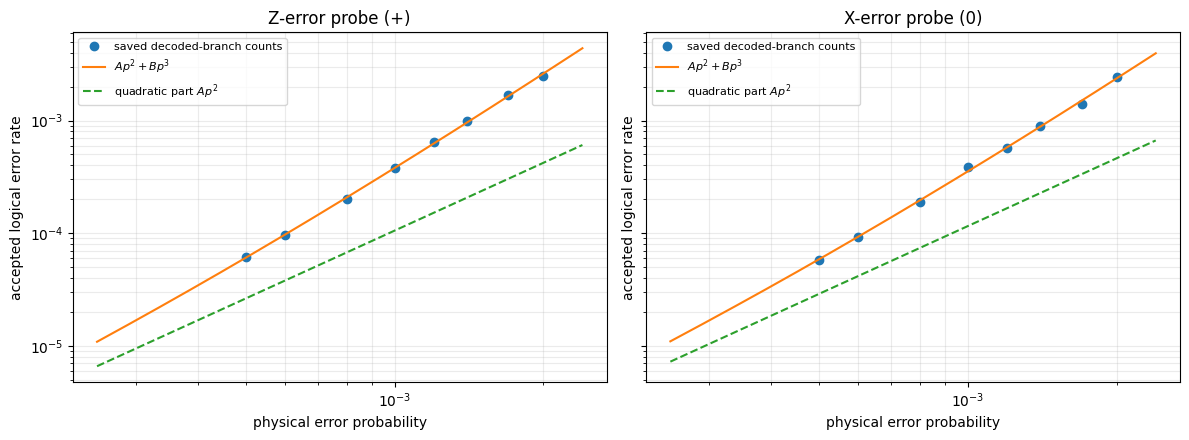

,probe,A (p^2 coefficient),B (p^3 coefficient),A/B crossover p,window power-law slope,local slope at p=0.001
0,+,105.275210,273571.599367,0.000385,2.726869,2.722117
1,0,115.605111,238129.019633,0.000485,2.683213,2.673186


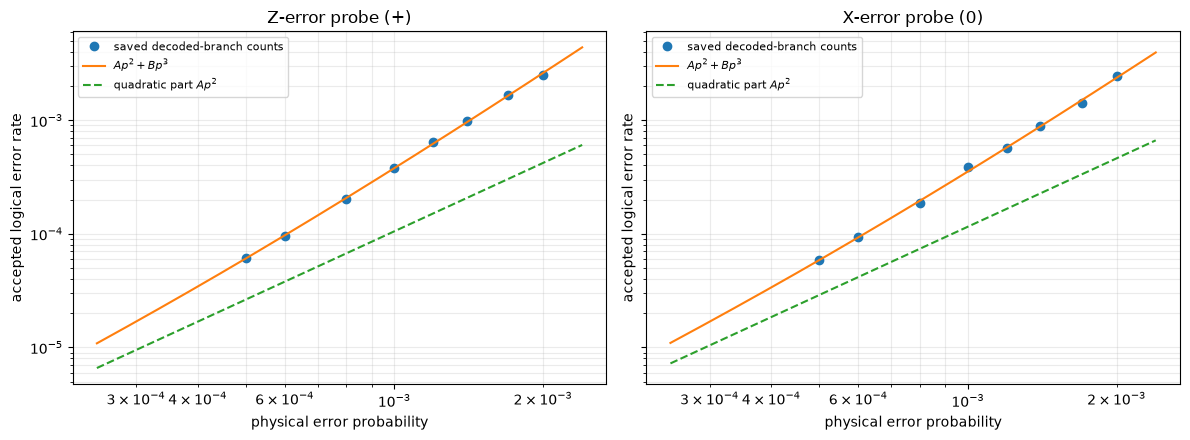

In [34]:
scaling = pd.read_csv(ROOT / "audit" / "false_branch_scaling_results.csv", dtype={"probe": str})
fit_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, probe, title in zip(axes, ["+", "0"], ["Z-error probe (+)", "X-error probe (0)"]):
    data = scaling[scaling["probe"] == probe]
    p = data["p"].to_numpy()
    rate = data["logical_error_rate"].to_numpy()
    errors = data["errors"].to_numpy()
    design = np.column_stack([p**2, p**3])
    weights = np.sqrt(errors) / rate
    (A, B), _ = nnls(design * weights[:, None], rate * weights)
    prediction = A * p**2 + B * p**3
    effective_slope = 2 + B * p / (A + B * p)
    power_fit = np.polyfit(np.log(p), np.log(rate), 1, w=np.sqrt(errors))
    fit_rows.append(
        {
            "probe": probe,
            "A (p^2 coefficient)": A,
            "B (p^3 coefficient)": B,
            "A/B crossover p": A / B,
            "window power-law slope": power_fit[0],
            "local slope at p=0.001": 2 + B * 0.001 / (A + B * 0.001),
        }
    )
    dense_p = np.geomspace(p.min() / 2, p.max() * 1.2, 300)
    ax.loglog(p, rate, "o", label="saved decoded-branch counts")
    ax.loglog(dense_p, A * dense_p**2 + B * dense_p**3, label=r"$A p^2+B p^3$")
    ax.loglog(dense_p, A * dense_p**2, "--", label=r"quadratic part $A p^2$")
    ax.set(title=title, xlabel="physical error probability", ylabel="accepted logical error rate")
    ax.grid(which="both", alpha=0.25)
    ax.legend(fontsize=8)
display(pd.DataFrame(fit_rows))
fig.tight_layout();

## 7. What to fix, in the order I would test it

1. **Decide the target behavior.** If “fault distance 3” means the paper's
   minimum-undetected-fault definition, the present circuit already has three;
   postselection or sufficiently strong complementary-gap rejection is what
   converts that into roughly $p^3$ accepted logical scaling. If the goal is
   $p^3$ **while decoding** surface syndromes, the combined transition must
   correct every pair of faults—effectively a distance-5 spacetime target.
2. **Increase the bottleneck depth first.** Parameterize the three
   merged-boundary/interface rounds and try five, while extending the
   compatible surface detector record and the color/demolition schedule. Merely
   appending more surface-only rounds after demolition is not enough.
3. **Repair the temporal corner exposed by `D16–D46–D77`.** Add/reconstruct
   independent information at the initial surface-Z and demolition/interface
   boundaries so that two reset/readout-history faults cannot share endpoints
   with the initial-boundary-plus-interface-data history.
4. **Then optimize the CNOT hooks.** Reorder/orient the surface CNOTs and/or add
   flags so the `+`-probe correlated faults do not align with a short logical
   homology. This can reduce or remove the shown Z-error witness, but the `0`
   witness shows that hook work alone cannot restore cubic decoded scaling.
5. **Do not judge a repair from a slope first.** The regression gate should be
   exact: no accepted one-fault decoder failures and no accepted two-fault
   same-syndrome/opposite-`L0` class. Only then run modest Monte Carlo. The
   tens-of-billions-shot full-postselection sweep is unnecessary for debugging.

An improved decoder alone cannot distinguish the displayed pairs because their
available detector strings are literally equal. A conditional or correlated
decoder may choose the more likely class and reduce the coefficient, but it
cannot make the $p^2$ term vanish unless the circuit supplies additional
information or rejects those syndromes.

In [35]:
assert branch_table.loc[branch_table.full_post_selection == False, "postselected_detectors"].item() == 40
assert branch_table.loc[branch_table.full_post_selection == True, "postselected_detectors"].item() == 135
assert plus_pairs["common_accepted_syndrome"].map(tuple).nunique() == 1
assert zero_pairs["common_accepted_syndrome"].map(tuple).nunique() == 1
assert set(plus_pairs["actual_L0"]) == {0, 1}
assert set(zero_pairs["actual_L0"]) == {0, 1}
print("All notebook audit assertions passed.")

All notebook audit assertions passed.
All notebook audit assertions passed.
